In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('Zillow.csv')
df.columns.tolist()

['parcelid',
 'airconditioningtypeid',
 'architecturalstyletypeid',
 'basementsqft',
 'bathroomcnt',
 'bedroomcnt',
 'buildingclasstypeid',
 'buildingqualitytypeid',
 'calculatedbathnbr',
 'decktypeid',
 'finishedfloor1squarefeet',
 'calculatedfinishedsquarefeet',
 'finishedsquarefeet12',
 'finishedsquarefeet13',
 'finishedsquarefeet15',
 'finishedsquarefeet50',
 'finishedsquarefeet6',
 'fips',
 'fireplacecnt',
 'fullbathcnt',
 'garagecarcnt',
 'garagetotalsqft',
 'hashottuborspa',
 'heatingorsystemtypeid',
 'latitude',
 'longitude',
 'lotsizesquarefeet',
 'poolcnt',
 'poolsizesum',
 'pooltypeid10',
 'pooltypeid2',
 'pooltypeid7',
 'propertycountylandusecode',
 'propertylandusetypeid',
 'propertyzoningdesc',
 'rawcensustractandblock',
 'regionidcity',
 'regionidcounty',
 'regionidneighborhood',
 'regionidzip',
 'roomcnt',
 'storytypeid',
 'threequarterbathnbr',
 'typeconstructiontypeid',
 'unitcnt',
 'yardbuildingsqft17',
 'yardbuildingsqft26',
 'yearbuilt',
 'numberofstories',
 'firep

In [3]:
to_remove = []
for col in df.columns:
    if df[col].nunique() == 1:
        to_remove.append(col)

    elif(df[col].isnull().mean() > 0.50):
        to_remove.append(col)

print(f"Columns to remove: {to_remove}")


Columns to remove: ['airconditioningtypeid', 'architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'decktypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'regionidneighborhood', 'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'fireplaceflag', 'assessmentyear', 'taxdelinquencyflag', 'taxdelinquencyyear']


In [4]:
df.drop(to_remove,
        axis=1,
        inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   bathroomcnt                   77579 non-null  float64
 2   bedroomcnt                    77579 non-null  float64
 3   buildingqualitytypeid         49809 non-null  float64
 4   calculatedbathnbr             76963 non-null  float64
 5   calculatedfinishedsquarefeet  77378 non-null  float64
 6   finishedsquarefeet12          73923 non-null  float64
 7   fips                          77579 non-null  float64
 8   fullbathcnt                   76963 non-null  float64
 9   heatingorsystemtypeid         49571 non-null  float64
 10  latitude                      77579 non-null  float64
 11  longitude                     77579 non-null  float64
 12  lotsizesquarefeet             69321 non-null  float64
 13  p

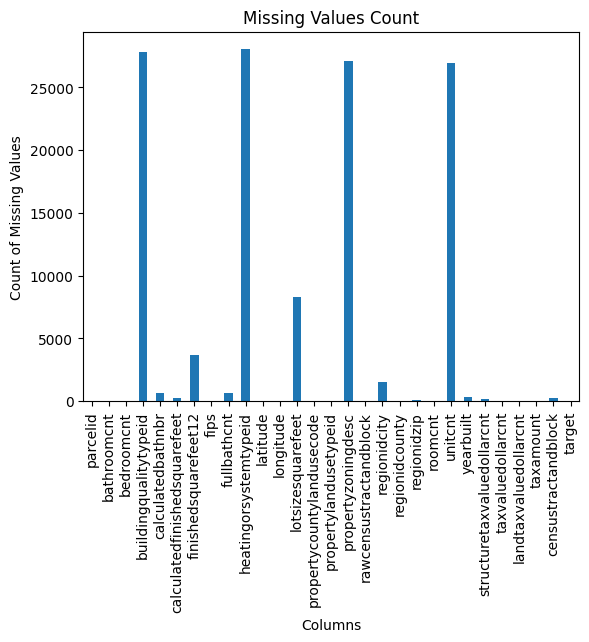

In [5]:
df.isnull().sum().plot.bar()
plt.title('Missing Values Count')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.show()

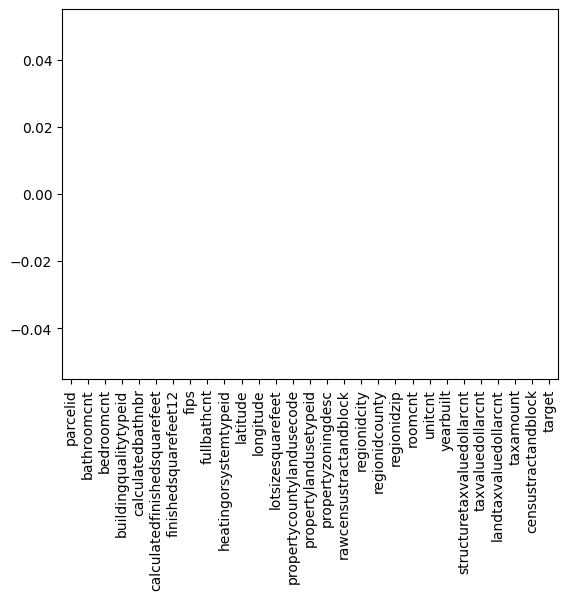

In [10]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    elif df[col].dtype == np.number:
        df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

df.isnull().sum().plot.bar()
plt.show()


EXPLORATORY DATA ANALYSIS

In [11]:
ints, objects, floats = [], [], []
for col in df.columns:
    if df[col].dtype ==  "object":
        objects.append(col)
    elif df[col].dtype == "int64":
        ints.append(col)
    elif df[col].dtype == "float64":
        floats.append(col)

len(ints), len(objects), len(floats)

(1, 2, 26)

In [12]:
for col in objects:
    print(f"unique value in column {col} is {df[col].nunique()}")
    print(f"unique value in column {col} is {df[col].unique()}")
    print("--------------------------------------------------")
    

unique value in column propertycountylandusecode is 75
unique value in column propertycountylandusecode is ['122' '1110' '0101' '010C' '1129' '0100' '38' '34' '1111' '012C' '010V'
 '1' '0103' '010D' '0200' '010E' '0300' '96' '0104' '0400' '01DC' '01HC'
 '1321' '1410' '0108' '1128' '010G' '1720' '010H' '1210' '0102' '010F'
 '010M' '1117' '0201' '0700' '1722' '73' '0109' '0301' '01HE' '135' '0204'
 '0401' '070D' '0113' '0133' '0131' '1432' '040G' '1112' '1222' '1310'
 '1120' '0111' '1116' '1421' '0110' '0105' '012E' '0141' '1333' '0115'
 '040V' '010L' '040B' '012D' '0114' '0203' '030G' '0130' '105' '020G'
 '020M' '020E']
--------------------------------------------------
unique value in column propertyzoningdesc is 1907
unique value in column propertyzoningdesc is ['LAR1' 'LCR110000*' 'LAR3' ... 'HAR4-R2*' 'LCR1VV' 'BFA15000*']
--------------------------------------------------


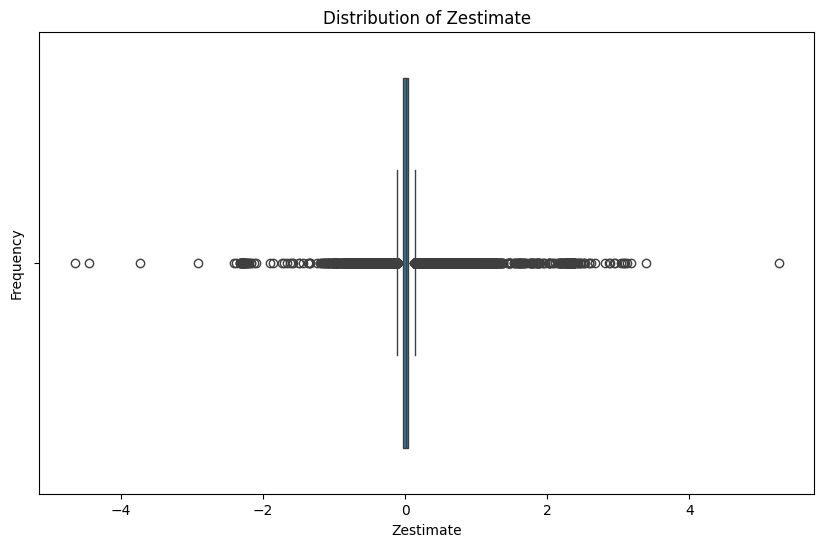

In [15]:
#plotting a boxplot
import seaborn as sb

plt.figure(figsize=(10, 6))
sb.boxplot(x=df['target'])
plt.title('Distribution of Zestimate')
plt.xlabel('Zestimate')
plt.ylabel('Frequency')
plt.show()

In [17]:
#remooving outliers
print(f"Shape of the dataset before removing outliers: {df.shape}"
      )
df = df[(df['target'] > -1) & (df['target'] < 1)]
print(f"Shape of the dataset after removing outliers: {df.shape}"
      )

Shape of the dataset before removing outliers: (77613, 29)
Shape of the dataset after removing outliers: (77261, 29)


In [19]:

from sklearn.preprocessing import LabelEncoder



for col in objects:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print('All categorical data has been encoded successfully')

All categorical data has been encoded successfully


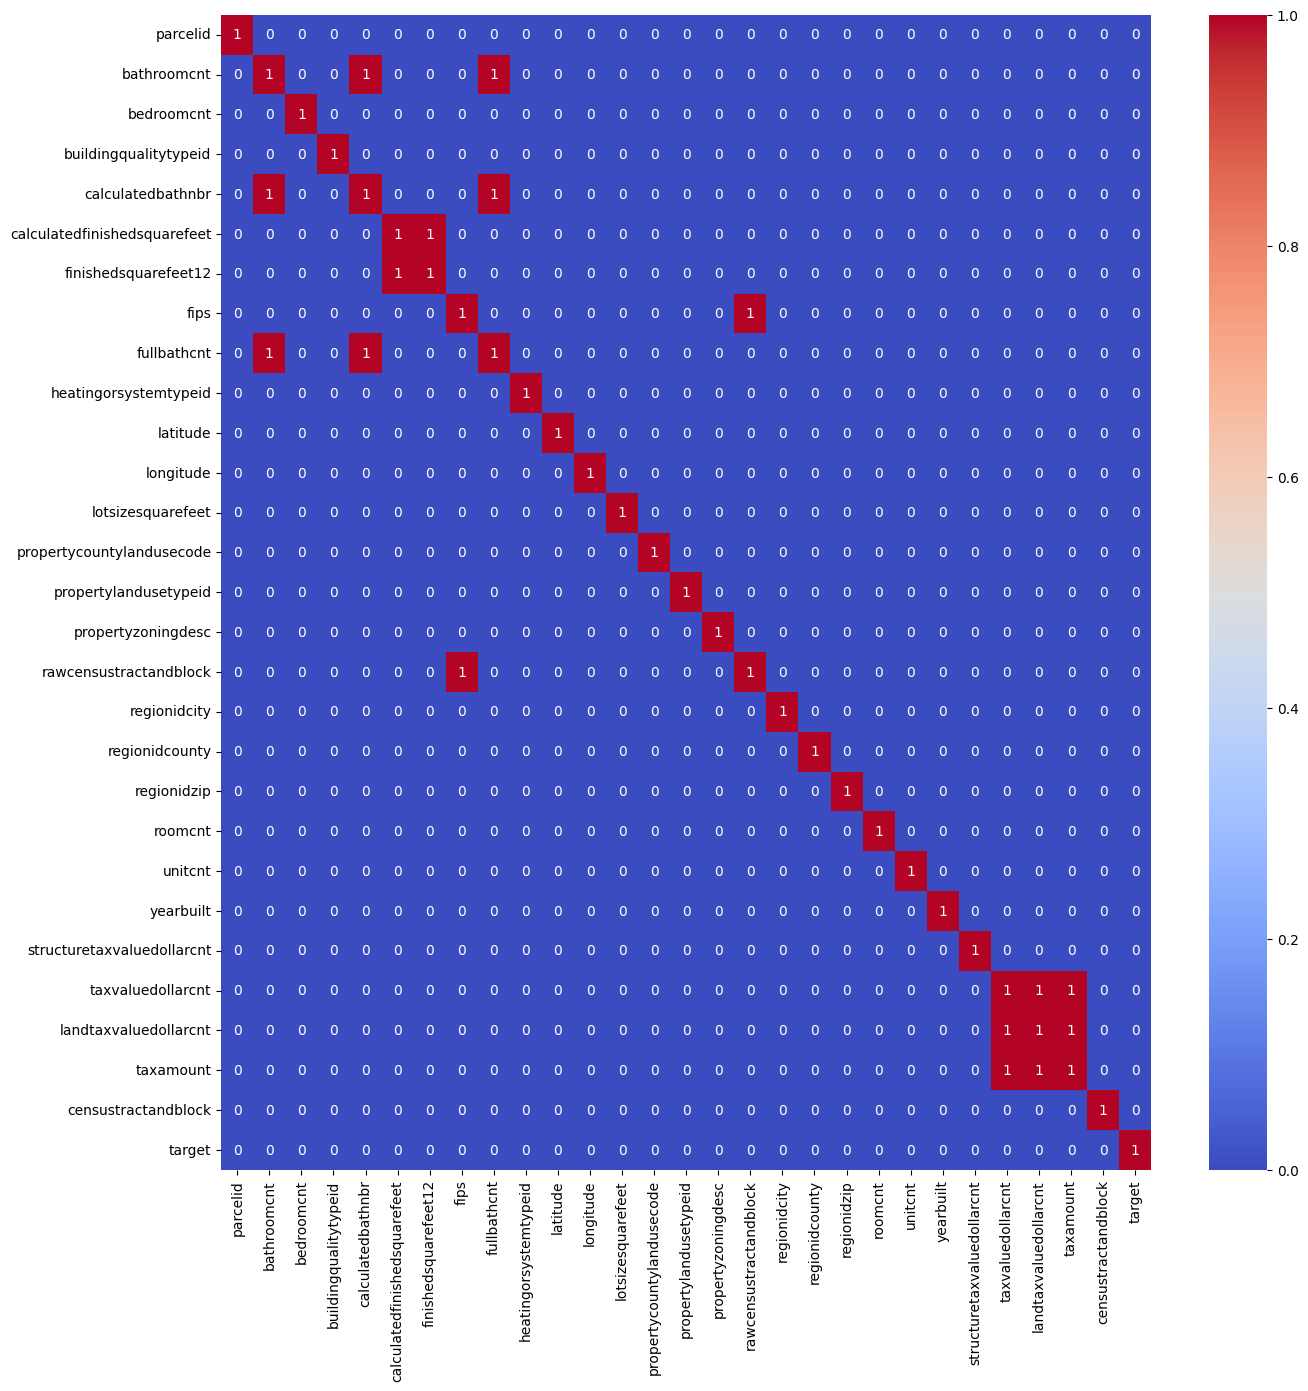

In [21]:
#show the correlation matrix
plt.figure(figsize=(15, 15))
sb.heatmap(df.corr() > 0.8, annot=True, cmap='coolwarm')
plt.show()

In [22]:
to_remove = ['calculatedbathnbr', 'fullbathcnt', 'fips',
             'rawcensustractandblock', 'taxvaluedollarcnt',
             'finishedsquarefeet12', 'landtaxvaluedollarcnt']

df.drop(to_remove, axis=1, inplace=True)

Model Training and dividing the dataset into train and test sets


In [24]:
features = df.drop(['parcelid'], axis=1)
target = df['target'].values
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

print(f"shape of the training set: {x_train.shape}")
print(f"shape of the test set: {x_test.shape}") 

shape of the training set: (61808, 21)
shape of the test set: (15453, 21)


In [26]:
#normalising the data
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.fit_transform(x_test)


In [27]:
from sklearn.metrics import mean_squared_error as mae 
models = [LinearRegression(), 
          XGBRegressor(),
          RandomForestRegressor(),
          Lasso(),
          Ridge()
          ]
for i in range(len(models)):
    models[i].fit(x_train_scaled, y_train)
    print('Name of the model: ', models[i])

    train_preds = models[i].predict(x_train_scaled)
    print('MAE of the training set: ', mae(y_train, train_preds))
    print('R2 score of the training set: ', r2_score(y_train, train_preds))


    #test predictions
    test_preds = models[i].predict(x_test_scaled)
    print('MAE of the test set: ', mae(y_test, test_preds))
    print('R2 score of the test set: ', r2_score(y_test, test_preds))
    print('--------------------------------------------------')

Name of the model:  LinearRegression()
MAE of the training set:  2.5608985979537527e-32
R2 score of the training set:  1.0
MAE of the test set:  8.617741584024575e-06
R2 score of the test set:  0.9993663992384264
--------------------------------------------------
Name of the model:  XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=N

In [28]:
print('All models have been trained and evaluated successfully')
print('Ladies and gentlemen, the winner is XGBRegressor with the lowest MAE and highest R2 score on the test set!')
print('Congratulations to XGBRegressor for its outstanding performance in predicting the Zestimate!')
print('the price is you get the next dataset')

All models have been trained and evaluated successfully
Ladies and gentlemen, the winner is XGBRegressor with the lowest MAE and highest R2 score on the test set!
Congratulations to XGBRegressor for its outstanding performance in predicting the Zestimate!
the price is you get the next dataset
